In [58]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import pymysql 

In [59]:
host = '127.0.0.1'
port = 3306
Username = 'root'
password = '7867'
database = 'bank_churn_db'

In [60]:
connection = pymysql.connect(host=host,user=Username,port=port,password=password,database=database)

In [61]:
Customers_Info_Table = pd.read_sql("""
            Select
            *
            from
            Customers_info
            """,con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_16464\4010057605.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  Customers_Info_Table = pd.read_sql("""


In [62]:
Customers_Info_Table

,CustomerId,CreditScore,Country,Gender,Age,Tenure,EstimatedSalary,Age_Groups,Credit_Score_Status
0,15634602,619,France,Female,42,2,101348.88,36-45,Fair
1,15647311,608,Spain,Female,41,1,112542.58,36-45,Fair
2,15619304,502,France,Female,42,8,113931.57,36-45,Poor
3,15701354,699,France,Female,39,1,93826.63,36-45,Good
4,15737888,850,Spain,Female,43,2,79084.10,36-45,Excellent
...,...,...,...,...,...,...,...,...,...
9995,15606229,771,France,Male,39,5,96270.64,36-45,Excellent
9996,15569892,516,France,Male,35,10,101699.77,26-35,Poor
9997,15584532,709,France,Female,36,7,42085.58,36-45,Good
9998,15682355,772,Germany,Male,42,3,92888.52,36-45,Excellent


In [63]:
Accounts_info_table = pd.read_sql("""
            Select
            *
            from
            Account_info
            """,con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_16464\450885025.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  Accounts_info_table = pd.read_sql("""


In [64]:
Accounts_info_table

,CustomerId,Balance,NumOfProducts,Has_Credit_Card,IsActiveMember,Exited,Balance_Category
0,15634602,0.00,1,Yes,Yes,1,0
1,15647311,83807.86,1,Yes,Yes,0,50001-150000
2,15619304,159660.80,3,No,No,1,150001+
3,15701354,0.00,2,No,No,0,0
4,15737888,125510.82,1,Yes,Yes,0,50001-150000
...,...,...,...,...,...,...,...
9995,15606229,0.00,2,No,No,0,0
9996,15569892,57369.61,1,Yes,Yes,0,50001-150000
9997,15584532,0.00,1,Yes,Yes,1,0
9998,15682355,75075.31,2,No,No,1,50001-150000


# Analysis Using SQL and Python

In [65]:
df = pd.read_sql("""
            Select
            *
            from
            customers_info as ci
            Inner Join account_info as ai
            On ci.CustomerId = ai.CustomerId
            """,con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_16464\694749780.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


In [66]:
df.head()

,CustomerId,CreditScore,Country,Gender,Age,Tenure,EstimatedSalary,Age_Groups,Credit_Score_Status,CustomerId,Balance,NumOfProducts,Has_Credit_Card,IsActiveMember,Exited,Balance_Category
0,15634602,619,France,Female,42,2,101348.88,36-45,Fair,15634602,0.00,1,Yes,Yes,1,0
1,15647311,608,Spain,Female,41,1,112542.58,36-45,Fair,15647311,83807.86,1,Yes,Yes,0,50001-150000
2,15619304,502,France,Female,42,8,113931.57,36-45,Poor,15619304,159660.80,3,No,No,1,150001+
3,15701354,699,France,Female,39,1,93826.63,36-45,Good,15701354,0.00,2,No,No,0,0
4,15737888,850,Spain,Female,43,2,79084.10,36-45,Excellent,15737888,125510.82,1,Yes,Yes,0,50001-150000


# KPI's

In [67]:
### Total Customers 10000
pd.read_sql("""
            Select
            Count(*) as Total_Customers
            from
            customers_info as ci
            Inner Join account_info as ai
            On ci.CustomerId = ai.CustomerId
            """,con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_16464\3712654495.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("""


,Total_Customers
0,10000


In [68]:
# Customer Churn Rate      20.37 %
pd.read_sql("""
            Select
            (COUNT(Case WHEN Exited = 1 THEN Exited END) / COUNT(*))*100 as Churn_Rate
            from
            customers_info as ci
            Inner Join account_info as ai
            On ci.CustomerId = ai.CustomerId
            """,con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_16464\3091162649.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("""


,Churn_Rate
0,20.37


In [69]:
# Average Account balance 
pd.read_sql("""
            Select
           AVG(Balance) as Average_Account_Balance
            from
            customers_info as ci
            Inner Join account_info as ai
            On ci.CustomerId = ai.CustomerId
            """,con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_16464\2479432651.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("""


,Average_Account_Balance
0,76485.889288


In [70]:
# Average Credit Score  650.58288
pd.read_sql("""
            Select
           AVG(CreditScore) as Average_Credit_Score
            from
            customers_info as ci
            Inner Join account_info as ai
            On ci.CustomerId = ai.CustomerId
            """,con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_16464\3131556373.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("""


,Average_Credit_Score
0,650.5288


In [71]:
# Average Estimated Salary 100092.222656
pd.read_sql("""
            Select
           AVG(EstimatedSalary) as Average_Estimated_Salary
            from
            customers_info as ci
            Inner Join account_info as ai
            On ci.CustomerId = ai.CustomerId
            """,con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_16464\3799538281.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("""


,Average_Estimated_Salary
0,100092.222656


In [72]:
# Active Vs Non Active Customers
pd.read_sql("""
            Select
            isActiveMember,
            COUNT(*) as No_of_Customers
            from
            customers_info as ci
            Inner Join account_info as ai
            On ci.CustomerId = ai.CustomerId
            group by isActiveMember
            """,con=connection) 

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_16464\2652457698.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("""


,isActiveMember,No_of_Customers
0,Yes,5151
1,No,4849


In [73]:
# Average Tenure ### 5.0128
pd.read_sql("""
            Select
            AVG(Tenure) as Average_Tenure
            from
            customers_info as ci
            Inner Join account_info as ai
            On ci.CustomerId = ai.CustomerId
            """,con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_16464\3978319677.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("""


,Average_Tenure
0,5.0128


In [74]:
# Average AGE  38.9215
pd.read_sql("""
            Select
            AVG(AGE) as Average_AGE
            from
            customers_info as ci
            Inner Join account_info as ai
            On ci.CustomerId = ai.CustomerId
            """,con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_16464\2751767258.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("""


,Average_AGE
0,38.9215


# Deeper Analysis Using Python Visualization

In [75]:
pd.read_sql("""
            Select
            *
            from
            customers_info as ci
            Inner Join account_info as ai
            On ci.CustomerId = ai.CustomerId
            """,con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_16464\1914769381.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("""


,CustomerId,CreditScore,Country,Gender,Age,Tenure,EstimatedSalary,Age_Groups,Credit_Score_Status,CustomerId,Balance,NumOfProducts,Has_Credit_Card,IsActiveMember,Exited,Balance_Category
0,15634602,619,France,Female,42,2,101348.88,36-45,Fair,15634602,0.00,1,Yes,Yes,1,0
1,15647311,608,Spain,Female,41,1,112542.58,36-45,Fair,15647311,83807.86,1,Yes,Yes,0,50001-150000
2,15619304,502,France,Female,42,8,113931.57,36-45,Poor,15619304,159660.80,3,No,No,1,150001+
3,15701354,699,France,Female,39,1,93826.63,36-45,Good,15701354,0.00,2,No,No,0,0
4,15737888,850,Spain,Female,43,2,79084.10,36-45,Excellent,15737888,125510.82,1,Yes,Yes,0,50001-150000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15696175,602,Germany,Male,35,7,51695.41,26-35,Fair,15696175,90602.42,2,Yes,Yes,0,50001-150000
9996,15798964,714,Germany,Male,33,3,53667.08,26-35,Good,15798964,35016.60,1,No,No,0,1-50000
9997,15657105,726,Spain,Male,36,2,195192.40,36-45,Good,15657105,0.00,1,No,No,0,0
9998,15719294,800,France,Female,29,2,167773.55,26-35,Excellent,15719294,0.00,2,No,No,0,0


In [76]:
df = Customers_Info_Table.merge(Accounts_info_table)

In [77]:
df.head()

,CustomerId,CreditScore,Country,Gender,Age,Tenure,EstimatedSalary,Age_Groups,Credit_Score_Status,Balance,NumOfProducts,Has_Credit_Card,IsActiveMember,Exited,Balance_Category
0,15634602,619,France,Female,42,2,101348.88,36-45,Fair,0.00,1,Yes,Yes,1,0
1,15647311,608,Spain,Female,41,1,112542.58,36-45,Fair,83807.86,1,Yes,Yes,0,50001-150000
2,15619304,502,France,Female,42,8,113931.57,36-45,Poor,159660.80,3,No,No,1,150001+
3,15701354,699,France,Female,39,1,93826.63,36-45,Good,0.00,2,No,No,0,0
4,15737888,850,Spain,Female,43,2,79084.10,36-45,Excellent,125510.82,1,Yes,Yes,0,50001-150000


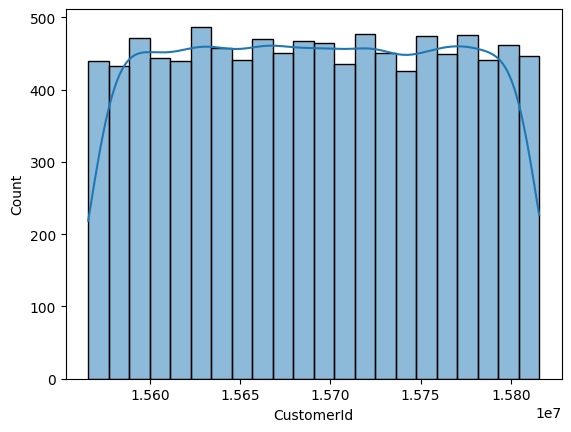

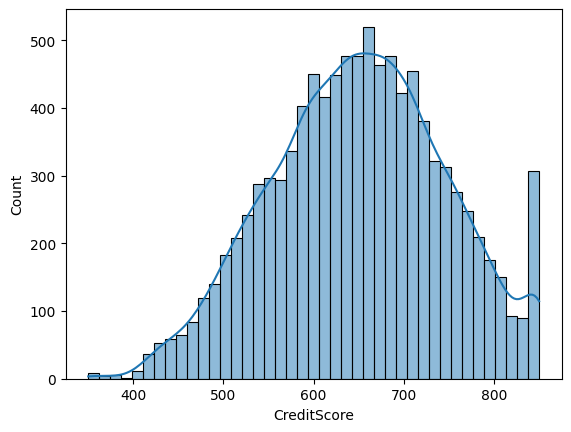

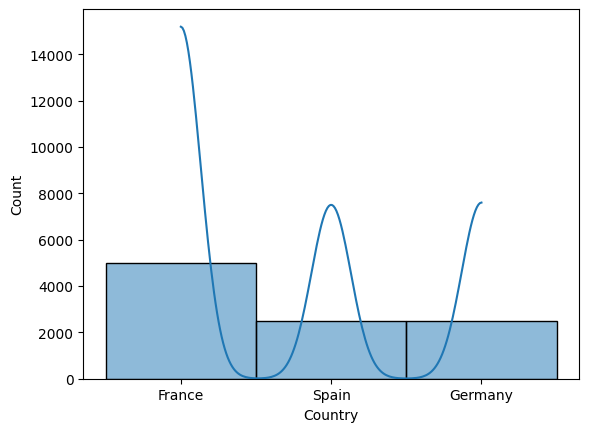

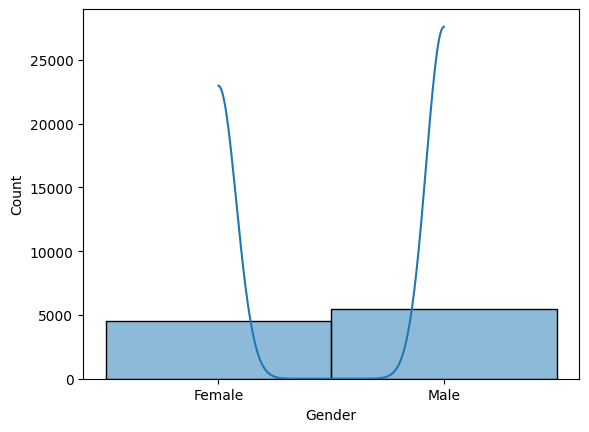

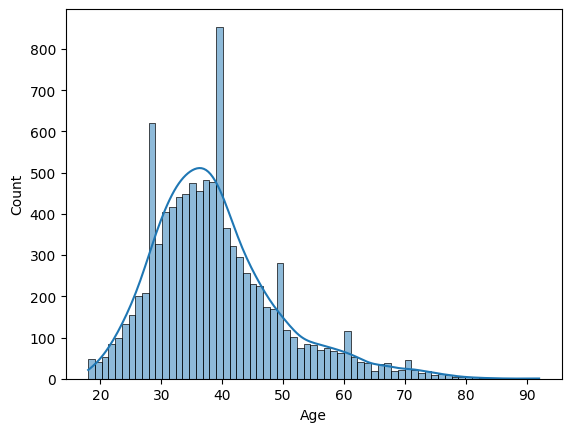

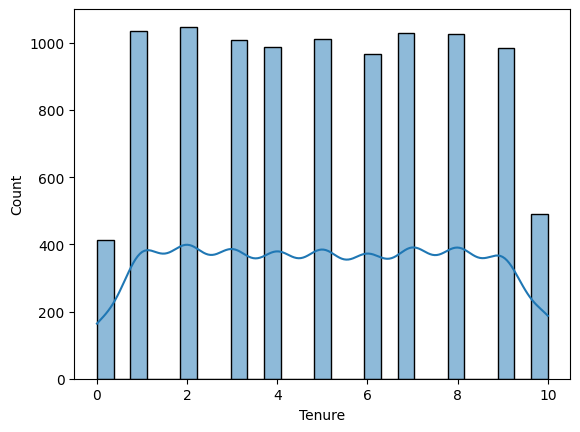

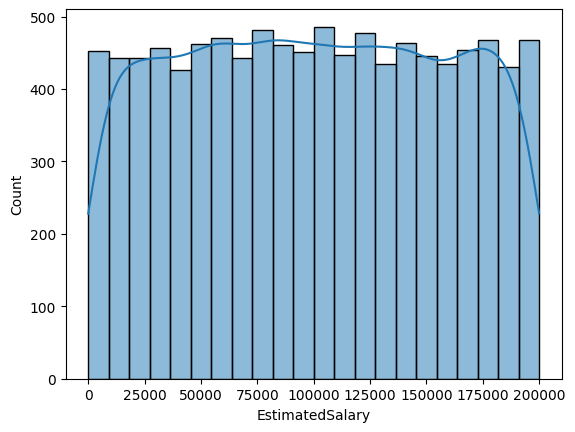

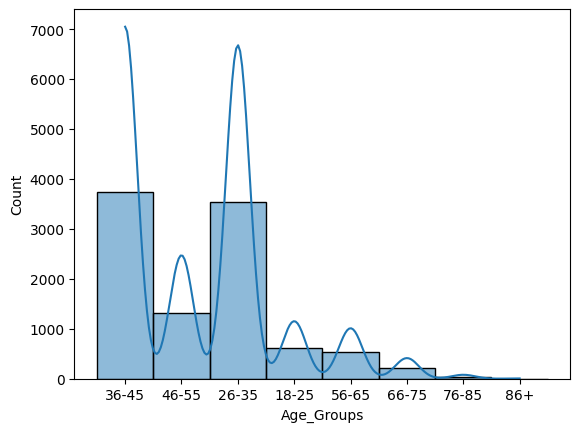

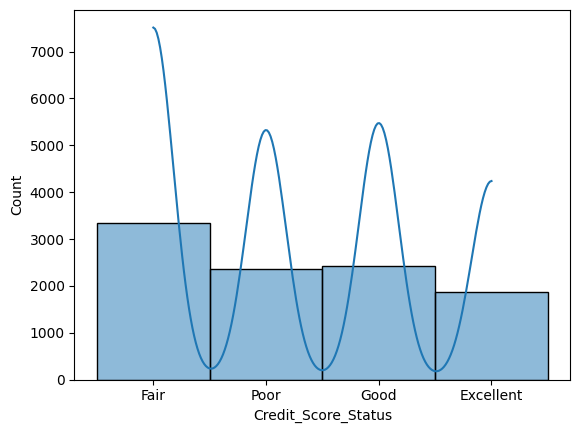

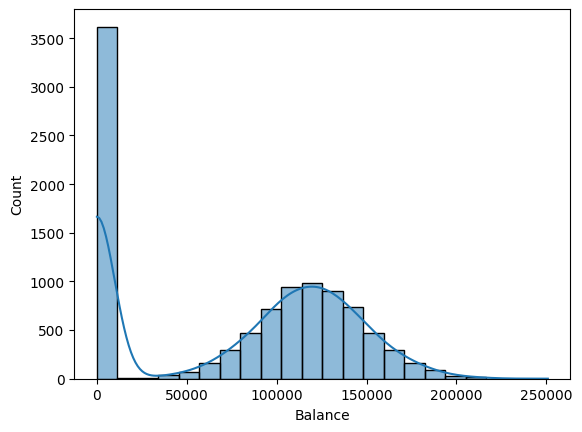

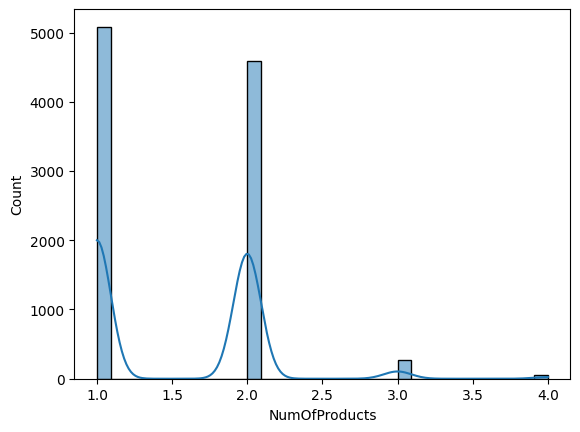

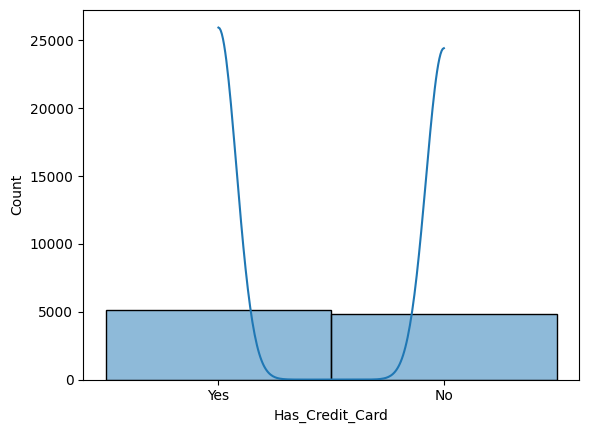

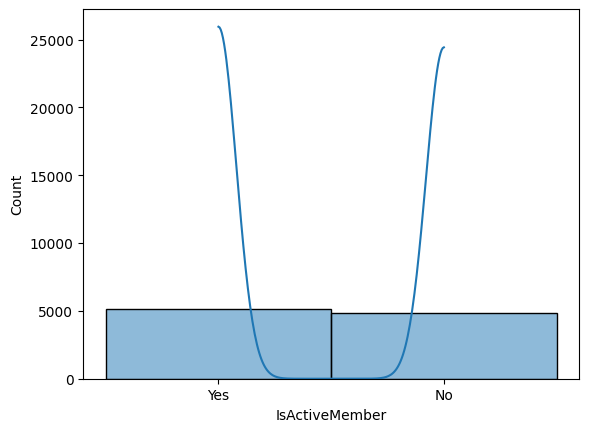

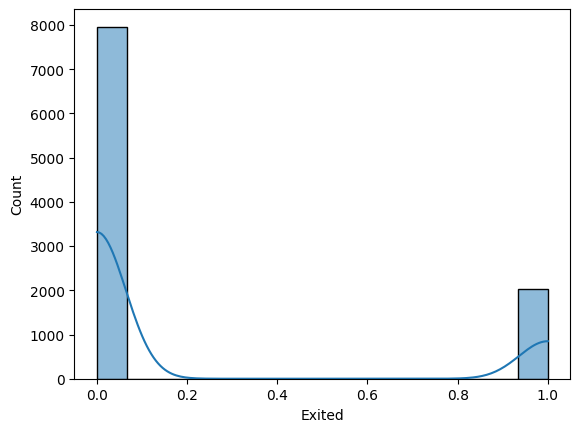

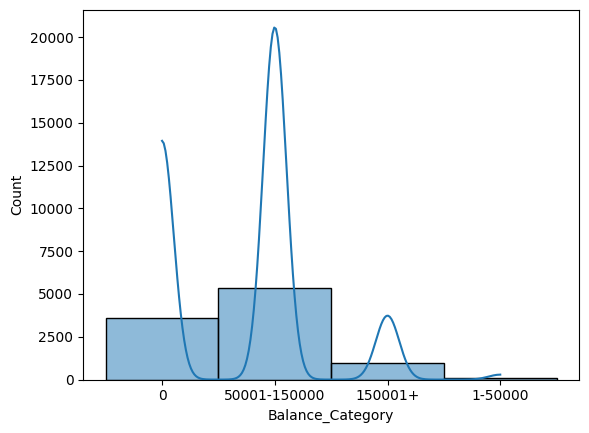

In [78]:
### There are outliers as well but i will keep them as they can indicate important things 

for i in df.columns:
    sns.histplot(data=df,x=i,kde=True)
    plt.show()

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_16464\1928266977.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['Exited']==0]['Age'],label='Not Exited',hist=False)
C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_16464\1928266977.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.

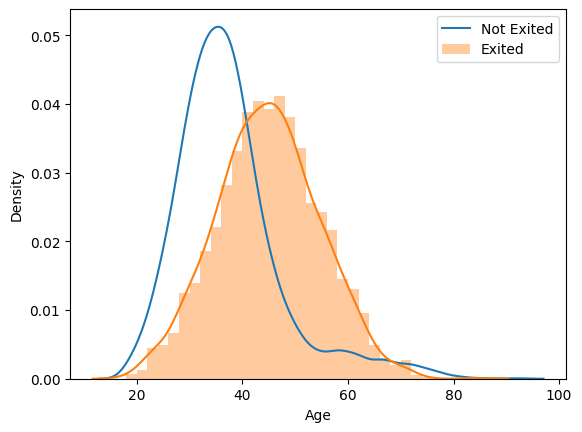

In [79]:
### Probability plot 
#sns.displot(df(df['Exited']==0['Age'],label='Not Left'))
sns.distplot(df[df['Exited']==0]['Age'],label='Not Exited',hist=False)
sns.distplot(df[df['Exited']==1]['Age'],label='Exited')
plt.legend()
plt.show()

#### After 40 years Old There is Great Probability of Customer to Left Bank 


C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_16464\1273291909.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['Exited']==0]['CreditScore'],label='Not Exited',hist=False)
C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_16464\1273291909.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

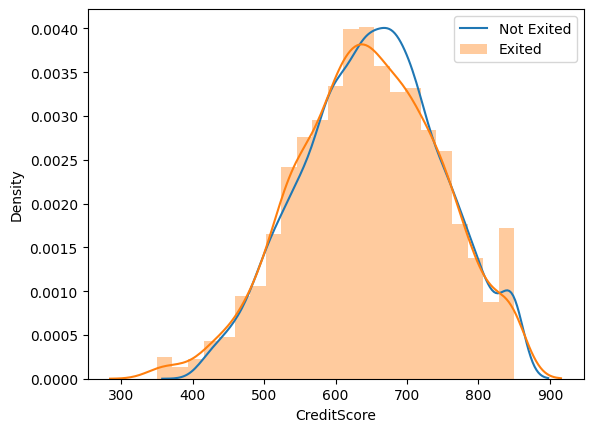

In [80]:
sns.distplot(df[df['Exited']==0]['CreditScore'],label='Not Exited',hist=False)
sns.distplot(df[df['Exited']==1]['CreditScore'],label='Exited')
plt.legend()
plt.show()

In [81]:
df.head()

,CustomerId,CreditScore,Country,Gender,Age,Tenure,EstimatedSalary,Age_Groups,Credit_Score_Status,Balance,NumOfProducts,Has_Credit_Card,IsActiveMember,Exited,Balance_Category
0,15634602,619,France,Female,42,2,101348.88,36-45,Fair,0.00,1,Yes,Yes,1,0
1,15647311,608,Spain,Female,41,1,112542.58,36-45,Fair,83807.86,1,Yes,Yes,0,50001-150000
2,15619304,502,France,Female,42,8,113931.57,36-45,Poor,159660.80,3,No,No,1,150001+
3,15701354,699,France,Female,39,1,93826.63,36-45,Good,0.00,2,No,No,0,0
4,15737888,850,Spain,Female,43,2,79084.10,36-45,Excellent,125510.82,1,Yes,Yes,0,50001-150000


C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_16464\496148344.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['Exited']==0]['Balance'],label='Not Exited',hist=False)
C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_16464\496148344.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sn

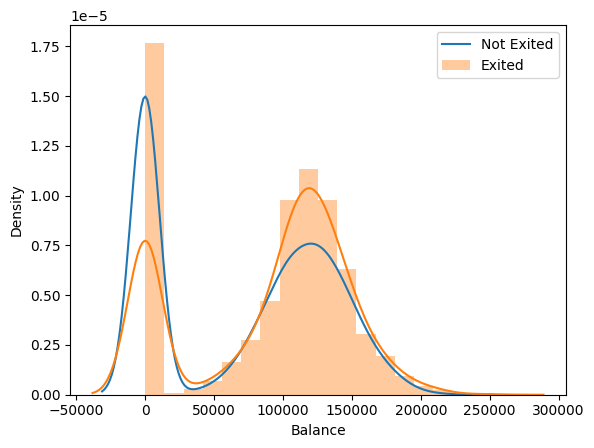

In [82]:
sns.distplot(df[df['Exited']==0]['Balance'],label='Not Exited',hist=False)
sns.distplot(df[df['Exited']==1]['Balance'],label='Exited')
plt.legend()
plt.show()

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_16464\3348373037.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['Exited']==0]['Tenure'],label='Not Exited',hist=False)
C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_16464\3348373037.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  s

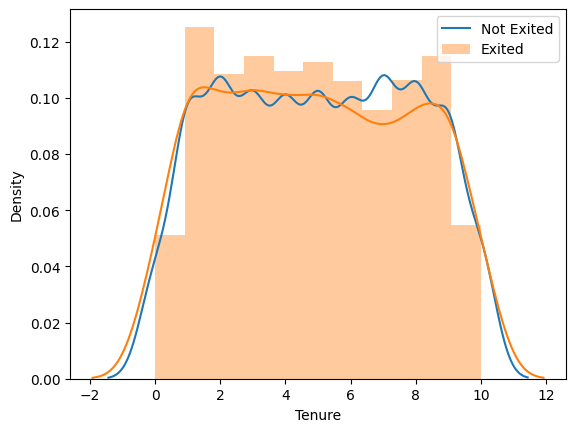

In [83]:
sns.distplot(df[df['Exited']==0]['Tenure'],label='Not Exited',hist=False)
sns.distplot(df[df['Exited']==1]['Tenure'],label='Exited')
plt.legend()
plt.show()

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_16464\3254002129.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['Exited']==0]['NumOfProducts'],label='Not Exited',hist=False)
C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_16464\3254002129.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe57

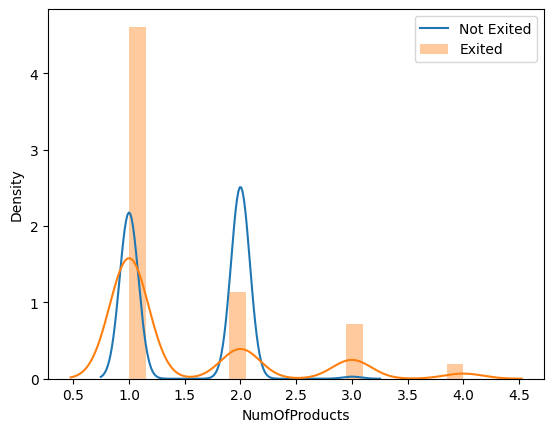

In [84]:
sns.distplot(df[df['Exited']==0]['NumOfProducts'],label='Not Exited',hist=False)
sns.distplot(df[df['Exited']==1]['NumOfProducts'],label='Exited')
plt.legend()
plt.show()

# More Questions to Answer

In [85]:
pd.read_sql("""
            Select
            *
            from
            customers_info as ci
            Inner Join account_info as ai
            On ci.CustomerId = ai.CustomerId
            """,con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_16464\1914769381.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("""


,CustomerId,CreditScore,Country,Gender,Age,Tenure,EstimatedSalary,Age_Groups,Credit_Score_Status,CustomerId,Balance,NumOfProducts,Has_Credit_Card,IsActiveMember,Exited,Balance_Category
0,15634602,619,France,Female,42,2,101348.88,36-45,Fair,15634602,0.00,1,Yes,Yes,1,0
1,15647311,608,Spain,Female,41,1,112542.58,36-45,Fair,15647311,83807.86,1,Yes,Yes,0,50001-150000
2,15619304,502,France,Female,42,8,113931.57,36-45,Poor,15619304,159660.80,3,No,No,1,150001+
3,15701354,699,France,Female,39,1,93826.63,36-45,Good,15701354,0.00,2,No,No,0,0
4,15737888,850,Spain,Female,43,2,79084.10,36-45,Excellent,15737888,125510.82,1,Yes,Yes,0,50001-150000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15696175,602,Germany,Male,35,7,51695.41,26-35,Fair,15696175,90602.42,2,Yes,Yes,0,50001-150000
9996,15798964,714,Germany,Male,33,3,53667.08,26-35,Good,15798964,35016.60,1,No,No,0,1-50000
9997,15657105,726,Spain,Male,36,2,195192.40,36-45,Good,15657105,0.00,1,No,No,0,0
9998,15719294,800,France,Female,29,2,167773.55,26-35,Excellent,15719294,0.00,2,No,No,0,0


# Customer Overview Tab 

### Customers By Gender and Products

In [86]:
Customers_By_Gender_And_Products = pd.read_sql("""
            Select
            Gender,
            Count(*) as No_OF_Customers
            from
            customers_info as ci
            Inner Join account_info as ai
            On ci.CustomerId = ai.CustomerId
            group by Gender
            """,con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_16464\3289744571.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  Customers_By_Gender_And_Products = pd.read_sql("""


In [87]:
Customers_By_Gender_And_Products

,Gender,No_OF_Customers
0,Female,4543
1,Male,5457


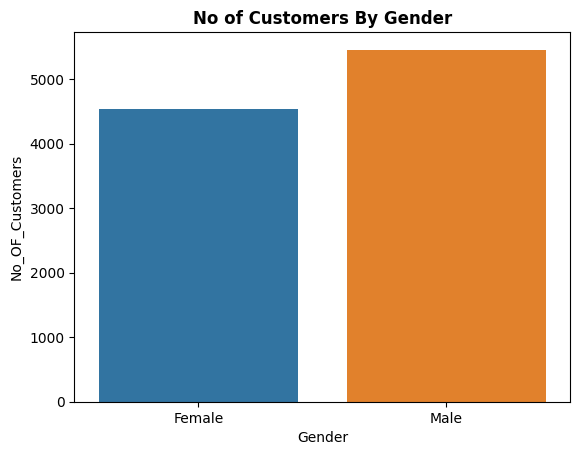

In [88]:
##### Male Customers are More As Compared To Female Customers


plt.title('No of Customers By Gender',fontdict={'fontweight':'bold'})
sns.barplot(data=Customers_By_Gender_And_Products,x='Gender',y='No_OF_Customers',hue='Gender')
plt.show()

### No of Customers By Country 

In [89]:
No_of_Customers_By_Country = pd.read_sql("""
            Select
            Country,
            Count(*) as No_OF_Customers
            from
            customers_info as ci
            Inner Join account_info as ai
            On ci.CustomerId = ai.CustomerId
            group by Country
            """,con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_16464\1349601160.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  No_of_Customers_By_Country = pd.read_sql("""


In [90]:
No_of_Customers_By_Country

,Country,No_OF_Customers
0,France,5014
1,Spain,2477
2,Germany,2509


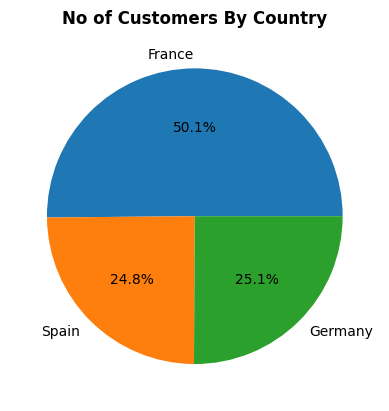

In [91]:
plt.title('No of Customers By Country',fontdict={'fontweight':'bold'})
plt.pie(data=No_of_Customers_By_Country,labels=No_of_Customers_By_Country['Country'].values,x=No_of_Customers_By_Country['No_OF_Customers'].values,autopct='%1.1f%%')
plt.show()

### Customers By Tenure 

In [92]:
No_of_Customers_By_Tenure = pd.read_sql("""
            Select
            ci.Tenure,
            Count(*) as No_OF_Customers
            from
            customers_info as ci
            Inner Join account_info as ai
            On ci.CustomerId = ai.CustomerId
            group by Tenure
            """,con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_16464\1229769856.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  No_of_Customers_By_Tenure = pd.read_sql("""


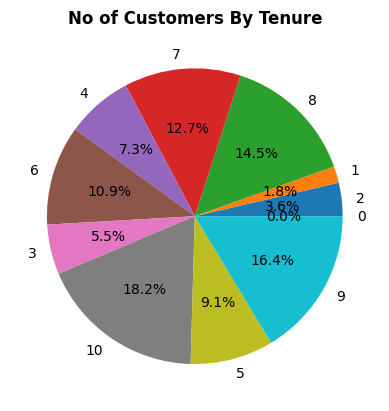

In [93]:
plt.title('No of Customers By Tenure',fontdict={'fontweight':'bold'})
plt.pie(data=No_of_Customers_By_Tenure,labels=No_of_Customers_By_Tenure['Tenure'].values,x=No_of_Customers_By_Tenure['Tenure'].values,autopct='%1.1f%%')
plt.show()

### No of Customers By CreditCard and isActiveMember

In [136]:
No_of_Customers_By_Has_Credit_Card = pd.read_sql("""
            Select
            Has_Credit_Card,
            Count(*) as No_OF_Customers
            from
            customers_info as ci
            Inner Join account_info as ai
            On ci.CustomerId = ai.CustomerId
            group by Has_Credit_Card
            """,con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_16464\3331754663.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  No_of_Customers_By_Has_Credit_Card = pd.read_sql("""


In [137]:
No_of_Customers_By_CreditCard_IsActiveMember

,Has_Credit_Card,No_OF_Customers
0,Yes,5151
1,No,4849


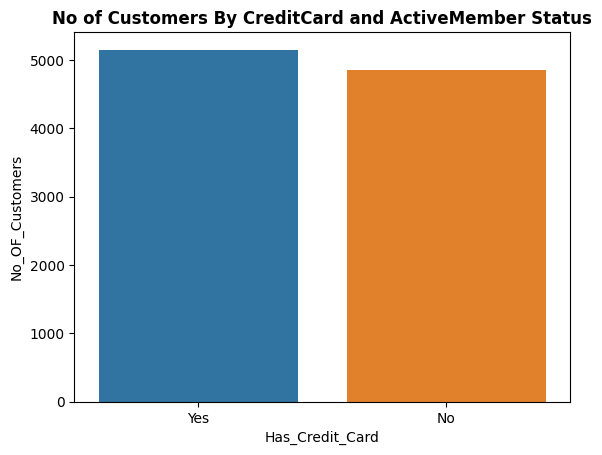

In [138]:
plt.title('No of Customers By CreditCard and ActiveMember Status',fontdict={'fontweight':'bold'})
sns.barplot(data=No_of_Customers_By_CreditCard_IsActiveMember,x='Has_Credit_Card',y='No_OF_Customers',hue='Has_Credit_Card')
plt.show()

# Churn Analysis 

In [97]:
df.head()

,CustomerId,CreditScore,Country,Gender,Age,Tenure,EstimatedSalary,Age_Groups,Credit_Score_Status,Balance,NumOfProducts,Has_Credit_Card,IsActiveMember,Exited,Balance_Category
0,15634602,619,France,Female,42,2,101348.88,36-45,Fair,0.00,1,Yes,Yes,1,0
1,15647311,608,Spain,Female,41,1,112542.58,36-45,Fair,83807.86,1,Yes,Yes,0,50001-150000
2,15619304,502,France,Female,42,8,113931.57,36-45,Poor,159660.80,3,No,No,1,150001+
3,15701354,699,France,Female,39,1,93826.63,36-45,Good,0.00,2,No,No,0,0
4,15737888,850,Spain,Female,43,2,79084.10,36-45,Excellent,125510.82,1,Yes,Yes,0,50001-150000


# Churn Rate By Age Group

In [98]:
Churn_Rate_By_Age_Groups = pd.read_sql("""
            Select
            Age_Groups,
            (COUNT(CASE WHEN Exited = 1 THEN Exited END)/COUNT(*)*100) as Churn_Rate
            from
            customers_info as ci
            Inner Join account_info as ai
            On ci.CustomerId = ai.CustomerId
            group by Age_Groups
            order by Age_Groups
            """,con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_16464\1468028993.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  Churn_Rate_By_Age_Groups = pd.read_sql("""


In [99]:
Churn_Rate_By_Age_Groups

,Age_Groups,Churn_Rate
0,18-25,7.5286
1,26-35,8.5004
2,36-45,19.6147
3,46-55,50.5721
4,56-65,48.3209
5,66-75,15.5251
6,76-85,2.3810
7,86+,0.0000


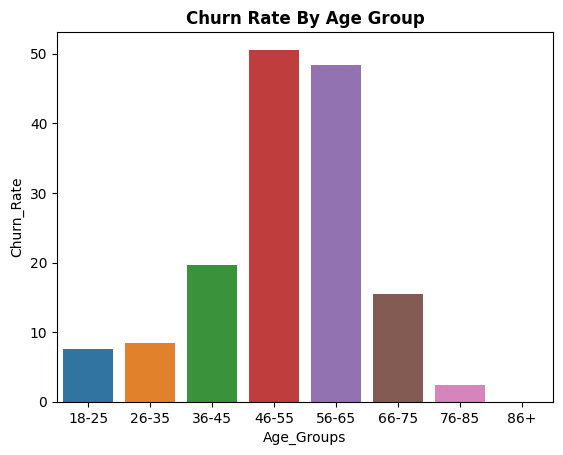

In [100]:
plt.title('Churn Rate By Age Group',fontdict={'fontweight':'bold'})
sns.barplot(data=Churn_Rate_By_Age_Groups,x='Age_Groups',y='Churn_Rate',hue='Age_Groups')
plt.show()

In [101]:
df.head()

,CustomerId,CreditScore,Country,Gender,Age,Tenure,EstimatedSalary,Age_Groups,Credit_Score_Status,Balance,NumOfProducts,Has_Credit_Card,IsActiveMember,Exited,Balance_Category
0,15634602,619,France,Female,42,2,101348.88,36-45,Fair,0.00,1,Yes,Yes,1,0
1,15647311,608,Spain,Female,41,1,112542.58,36-45,Fair,83807.86,1,Yes,Yes,0,50001-150000
2,15619304,502,France,Female,42,8,113931.57,36-45,Poor,159660.80,3,No,No,1,150001+
3,15701354,699,France,Female,39,1,93826.63,36-45,Good,0.00,2,No,No,0,0
4,15737888,850,Spain,Female,43,2,79084.10,36-45,Excellent,125510.82,1,Yes,Yes,0,50001-150000


# Churn Rate By Credit Score Status

In [102]:
Churn_By_Credit_Score_Status = pd.read_sql("""
            Select
            Credit_Score_Status,
            (COUNT(CASE WHEN Exited = 1 THEN Exited END)/COUNT(*)*100) as Churn_Rate
            from
            customers_info as ci
            Inner Join account_info as ai
            On ci.CustomerId = ai.CustomerId
            group by Credit_Score_Status
            """,con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_16464\505396241.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  Churn_By_Credit_Score_Status = pd.read_sql("""


In [103]:
Churn_By_Credit_Score_Status

,Credit_Score_Status,Churn_Rate
0,Fair,20.5644
1,Poor,22.0152
2,Good,18.6161
3,Excellent,20.2235


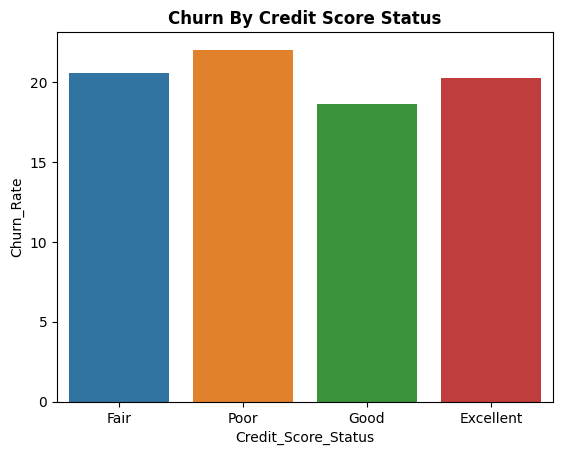

In [104]:
plt.title('Churn By Credit Score Status',fontdict={'fontweight':'bold'})
sns.barplot(data=Churn_By_Credit_Score_Status,x='Credit_Score_Status',y='Churn_Rate',hue='Credit_Score_Status')
plt.show()

# Churn Rate By Balance Status

In [110]:
Churn_Rate_By_Balance_Category = pd.read_sql("""
            Select
            Balance_Category,
            (COUNT(CASE WHEN Exited = 1 THEN Exited END)/COUNT(*)*100) as Churn_Rate
            from
            customers_info as ci
            Inner Join account_info as ai
            On ci.CustomerId = ai.CustomerId
            group by Balance_Category
            """,con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_16464\2521418385.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  Churn_Rate_By_Balance_Category = pd.read_sql("""


In [111]:
Churn_Rate_By_Balance_Category

,Balance_Category,Churn_Rate
0,0,13.8236
1,50001-150000,24.1056
2,150001+,23.1166
3,1-50000,34.6667


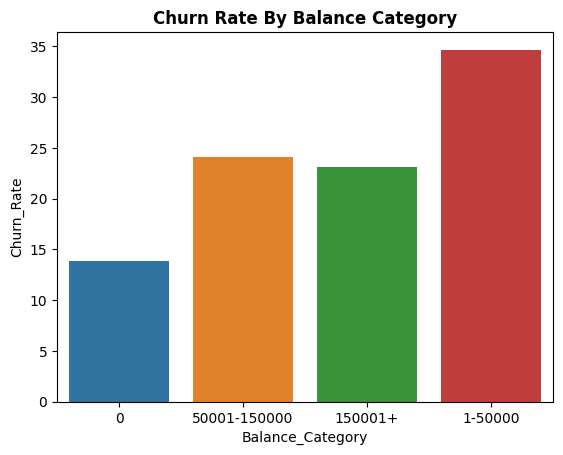

In [112]:
plt.title('Churn Rate By Balance Category',fontdict={'fontweight':'bold'})
sns.barplot(data=Churn_Rate_By_Balance_Category,x='Balance_Category',y='Churn_Rate',hue='Balance_Category')
plt.show()

In [113]:
df.head()

,CustomerId,CreditScore,Country,Gender,Age,Tenure,EstimatedSalary,Age_Groups,Credit_Score_Status,Balance,NumOfProducts,Has_Credit_Card,IsActiveMember,Exited,Balance_Category
0,15634602,619,France,Female,42,2,101348.88,36-45,Fair,0.00,1,Yes,Yes,1,0
1,15647311,608,Spain,Female,41,1,112542.58,36-45,Fair,83807.86,1,Yes,Yes,0,50001-150000
2,15619304,502,France,Female,42,8,113931.57,36-45,Poor,159660.80,3,No,No,1,150001+
3,15701354,699,France,Female,39,1,93826.63,36-45,Good,0.00,2,No,No,0,0
4,15737888,850,Spain,Female,43,2,79084.10,36-45,Excellent,125510.82,1,Yes,Yes,0,50001-150000


# Exit By Country

In [114]:
Customers_BY_Exit_Country = pd.read_sql("""
            Select
            Country,
            Exited,
            COUNT(*) as No_of_Customers
            from
            customers_info as ci
            Inner Join account_info as ai
            On ci.CustomerId = ai.CustomerId
            group by Country,Exited
            """,con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_16464\1890336567.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  Customers_BY_Exit_Country = pd.read_sql("""


In [115]:
Customers_BY_Exit_Country

,Country,Exited,No_of_Customers
0,France,1,810
1,Spain,0,2064
2,France,0,4204
3,Spain,1,413
4,Germany,1,814
5,Germany,0,1695


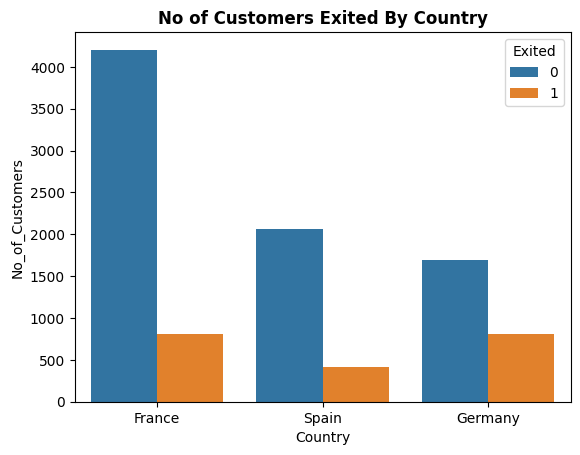

In [116]:
plt.title('No of Customers Exited By Country',fontdict={'fontweight':'bold'})
sns.barplot(data=Customers_BY_Exit_Country,x='Country',y='No_of_Customers',hue='Exited')
plt.show()

In [130]:
df.head()

,CustomerId,CreditScore,Country,Gender,Age,Tenure,EstimatedSalary,Age_Groups,Credit_Score_Status,Balance,NumOfProducts,Has_Credit_Card,IsActiveMember,Exited,Balance_Category
0,15634602,619,France,Female,42,2,101348.88,36-45,Fair,0.00,1,Yes,Yes,1,0
1,15647311,608,Spain,Female,41,1,112542.58,36-45,Fair,83807.86,1,Yes,Yes,0,50001-150000
2,15619304,502,France,Female,42,8,113931.57,36-45,Poor,159660.80,3,No,No,1,150001+
3,15701354,699,France,Female,39,1,93826.63,36-45,Good,0.00,2,No,No,0,0
4,15737888,850,Spain,Female,43,2,79084.10,36-45,Excellent,125510.82,1,Yes,Yes,0,50001-150000


In [131]:
Customes_Exited_NumProducts = pd.read_sql("""
            Select
            NumOfProducts,
            Exited,
            COUNT(*) as No_of_Customers
            from
            customers_info as ci
            Inner Join account_info as ai
            On ci.CustomerId = ai.CustomerId
            group by NumOfProducts,Exited
            """,con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_16464\1934691437.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  Customes_Exited_NumProducts = pd.read_sql("""


In [132]:
Customes_Exited_NumProducts

,NumOfProducts,Exited,No_of_Customers
0,1,1,1409
1,1,0,3675
2,3,1,220
3,2,0,4242
4,2,1,348
5,4,1,60
6,3,0,46


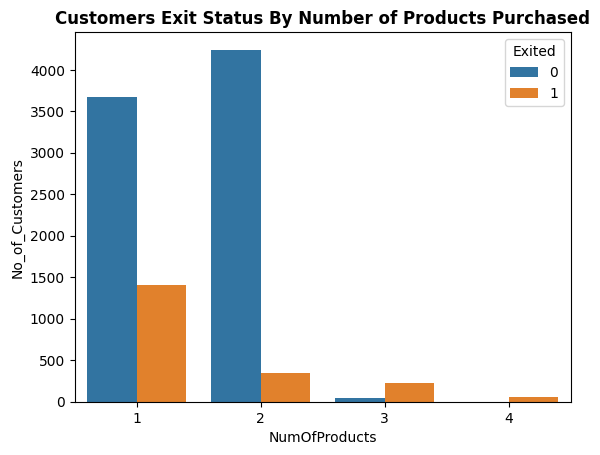

In [133]:
plt.title('Customers Exit Status By Number of Products Purchased',fontdict={'fontweight':'bold'})
sns.barplot(data=Customes_Exited_NumProducts,x='NumOfProducts',y='No_of_Customers',hue='Exited')
plt.show()

In [134]:
df.head()

,CustomerId,CreditScore,Country,Gender,Age,Tenure,EstimatedSalary,Age_Groups,Credit_Score_Status,Balance,NumOfProducts,Has_Credit_Card,IsActiveMember,Exited,Balance_Category
0,15634602,619,France,Female,42,2,101348.88,36-45,Fair,0.00,1,Yes,Yes,1,0
1,15647311,608,Spain,Female,41,1,112542.58,36-45,Fair,83807.86,1,Yes,Yes,0,50001-150000
2,15619304,502,France,Female,42,8,113931.57,36-45,Poor,159660.80,3,No,No,1,150001+
3,15701354,699,France,Female,39,1,93826.63,36-45,Good,0.00,2,No,No,0,0
4,15737888,850,Spain,Female,43,2,79084.10,36-45,Excellent,125510.82,1,Yes,Yes,0,50001-150000


In [135]:
df.to_csv(r'E:\Data Analyst Roadmap\Data Science Roadmap Campus X\Data Analytics Practice From Scratch\SQL+Python\Bank Churn Dataset/Bank_Churn_Viz_Ready.csv',index=False)